# 메일 -> CSV

In [56]:
# 메일 분류
def classify_mail(subject, body):
    text = (subject + " " + body).lower()

    categories = {
        "업무협조": [
            "협조", "요청", "부탁", "전달", "회신", "확인", "처리", "검토", "승인", "진행", "지원", "일정 요청", "자료 요청", "공유 요청", "확인 부탁", "전달 부탁"
        ],
        "보고서": [
            "보고", "결과", "분석", "현황", "매출", "데이터", "통계", "성과", "개선", "지표", "리포트", "요약"
        ],
        "회의록": [
            "회의", "회의록", "안건", "참석자", "일정", "논의", "결정", "진행", "의결", "회의 결과"
        ],
        "공지": [
            "공지", "안내", "알림", "변경", "일정", "공지사항", "배포", "적용", "공지드립니다", "참고"
        ]
    }

    scores = {key: 0 for key in categories}

    for category, keywords in categories.items():
        for kw in keywords:
            if kw in text:
                scores[category] += 1

    # 점수 가장 높은 카테고리 선택
    best_category = max(scores, key=scores.get)

    # 전부 0이면 fallback
    if scores[best_category] == 0:
        return "공지"  # 기본값 (가장 범용적)

    return best_category

In [ ]:
# 회신 여부 분류
def detect_action(body):
    need_reply_keywords = [
        "회신", "답변", "의견 부탁", "피드백", "확인 부탁",
        "검토 후 회신", "회신 요청", "답장"
    ]

    for kw in need_reply_keywords:
        if kw in body:
            return "회신 필요"

    return "회신 불필요"

In [58]:
# 기한 추출
def extract_deadline(body):
    patterns = [
        r"\d{4}[.-]\d{2}[.-]\d{2}",
        r"\d{2}[.-]\d{2}",
        r"\d{1,2}월\s?\d{1,2}일",
        r"\d{1,2}/\d{1,2}"
    ]

    for pattern in patterns:
        match = re.search(pattern, body)
        if match:
            return match.group()

    # "까지", "마감" 같은 문맥 기반 탐색
    deadline_keywords = ["까지", "마감", "기한"]
    for line in body.split("\n"):
        if any(k in line for k in deadline_keywords):
            return line.strip()

    return "-"

In [59]:
import imaplib
import email
from email.header import decode_header
import os
import pdfplumber
IMAP_SERVER = "imap.gmail.com"
EMAIL = 'mhnkms8041@gmail.com'
PASSWORD = 'qxvh ihup erwd ppgn'
SAVE_DIR = "./downloads"
os.makedirs(SAVE_DIR, exist_ok=True)
# 1. IMAP 접속
mail = imaplib.IMAP4_SSL(IMAP_SERVER)
mail.login(EMAIL, PASSWORD)
mail.select("inbox")

('OK', [b'20'])

In [60]:
# 2. 메일 검색 (제목 필터는 직접 처리)
result, data = mail.search(None, "ALL")
mail_ids = data[0].split()
mail_csv_list = []
target_mail = None
# 최근 메일부터 역순 탐색
for mail_id in reversed(mail_ids):
    result, data = mail.fetch(mail_id, "(RFC822)")
    raw_email = data[0][1]
    msg = email.message_from_bytes(raw_email)

    subject, encoding = decode_header(msg["Subject"])[0]
    if isinstance(subject, bytes):
        subject = subject.decode(encoding or "utf-8")

    # 필터 없이 전부 저장하거나 조건 유지 가능
    mail_csv_list.append(msg)
    # if "[업무협조]" in subject:
    #     print("대상 메일:", subject)
    #     mail_csv_list.append(msg)

In [ ]:
import csv
import re
import shutil

csv_path = "email_list.csv"
file_exists = os.path.isfile(csv_path)

with open(csv_path, "a", newline="", encoding="utf-8-sig") as csvfile:
    writer = csv.writer(csvfile)

    if not file_exists:
        # writer.writerow(["제목", "발신자", "분류", "액션", "기한", "요약"])
        writer.writerow(["제목", "발신자", "분류", "액션", "기한"])

    for mail_item in mail_csv_list:

        subject, encoding = decode_header(mail_item["Subject"])[0]
        if isinstance(subject, bytes):
            subject = subject.decode(encoding or "utf-8")

        from_ = str(email.header.make_header(decode_header(mail_item.get("From"))))

        full_text = ""
        saved_files = []   # ← 파일 경로 저장용

        for part in mail_item.walk():
            content_disposition = part.get("Content-Disposition")

            if part.get_content_type() == "text/plain" and "attachment" not in str(content_disposition):
                body = part.get_payload(decode=True)
                if body:
                    full_text += body.decode("utf-8", errors="ignore") + "\n"

            if content_disposition and "attachment" in content_disposition:
                filename = part.get_filename()

                if filename:
                    filename, enc = decode_header(filename)[0]
                    if isinstance(filename, bytes):
                        filename = filename.decode(enc or "utf-8")

                    if filename.lower().endswith(".pdf"):

                        # temp 폴더에 먼저 저장
                        temp_dir = os.path.join(SAVE_DIR, "temp")
                        os.makedirs(temp_dir, exist_ok=True)

                        temp_path = os.path.join(temp_dir, filename)

                        with open(temp_path, "wb") as f:
                            f.write(part.get_payload(decode=True))

                        saved_files.append(temp_path)

                        # PDF 텍스트 추출
                        with pdfplumber.open(temp_path) as pdf:
                            for page in pdf.pages:
                                text = page.extract_text()
                                if text:
                                    full_text += text + "\n"

        # 최종 분류 (PDF 기반)
        category = classify_mail(subject, full_text)

        # 폴더 생성
        category_dir = os.path.join(SAVE_DIR, category)
        os.makedirs(category_dir, exist_ok=True)

        # 파일 이동
        for temp_path in saved_files:
            filename = os.path.basename(temp_path)
            final_path = os.path.join(category_dir, filename)

            shutil.move(temp_path, final_path)
            #print(f"이동 완료: {final_path}")

        if os.path.exists(temp_dir) and not os.listdir(temp_dir):
            os.rmdir(temp_dir)

        # 분석
        action = detect_action(full_text)
        deadline = extract_deadline(full_text)

        writer.writerow([
            subject,
            from_,
            category,
            action,
            deadline
        ])

        print(f"처리 완료: {subject}")

print(f"\nCSV 저장 완료: {csv_path}")


CSV 저장 완료: email_list.csv


# 워드클라우드

In [62]:
!pip install wordcloud


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
# PDF 읽기
# 워드클라우드로 만들 보고서 이름
pdf_path = "./downloads/보고서/26년 4월 서비스 데이터 분석 종합 보고서.pdf"

text = ""

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        page_text = page.extract_text()
        if page_text:
            text += page_text + "\n"

print(text[:500])

[2026년 4월 서비스 데이터 분석 종합 보고서]
작성부서: 데이터분석팀
작성일자: 2026-04-30
1. 보고 목적
본 보고서는 2026년 4월 한 달간 서비스 이용 데이터를 종합적으로 분석하여
주요 성과 지표(KPI), 사용자 행동 패턴, 이상 징후 및 개선 필요 사항을 도출하고,
향후 서비스 운영 및 전략 수립에 참고 자료로 활용하기 위함이다.
2. 분석 개요
2.1 분석 기간
- 2026년 4월 1일 ~ 2026년 4월 30일
2.2 분석 대상
- 웹 및 모바일 서비스 전체 사용자
2.3 분석 도구
- 내부 로그 시스템
- 사용자 행동 분석 툴
- 데이터 웨어하우스 기반 SQL 분석
3. 주요 지표 요약
3.1 사용자 지표
- 총 방문자 수: 1,205,432명
- 신규 가입자 수: 84,213명
- 재방문율: 62.4%
3.2 이용 지표
- 평균 세션 시간: 6분 12초
- 페이지뷰(PV): 8,932,120회
- 일 평균 방문자 수: 약 40,181명
3.3 전환 지표


In [70]:
from konlpy.tag import Kkma
kkma = Kkma()
nouns = kkma.nouns("%r"%text)
print(nouns[:30])

['2026', '2026년', '년', '4', '4월', '월', '월', '서비스', '데이터', '분석', '종합', '보고서', '작성', '작성부서', '부서', '데이터분석팀', '팀', '작성일자', '일자', '-30', '1', '보고', '목적', '년', '달', '달간', '간', '간', '이용', '종합적']


In [77]:
from collections import Counter

word_list = kkma.nouns("%r"%text)
word_list = [w for w in word_list if len(w) > 1] # 너무 짧은 단어 제거
text = ' '.join(word_list)
text

'2026 2026년 4월 서비스 데이터 분석 종합 보고서 작성 작성부서 부서 데이터분석팀 작성일자 일자 -30 보고 목적 달간 이용 종합적 주요 성과 지표 사용자 행동 패턴 이상 징후 개선 필요 사항 도출 향후 운영 전략 수립 참고 자료 활용 2.1 기간 1일 30 30일 2.2 대상 모바일 전체 2.3 내부 로그 시스템 웨어 웨어하우스 하우스 기반 요약 3.1 방문자 1,205,432 1,205,432명 신규 가입자 84,213 84,213명 방문 62.4 3.2 평균 시간 6분 12 12초 페이지 페이지뷰 8,932,120 8,932,120회 40,181 40,181명 3.3 전환 회원 가입 6.98 결제 2.14 장바구니 바구니 이탈 48.7 4.1 증가 요인 중순 이후 수가 확인 15 15일 진행 마케팅 캠페인 영향 판단 광고 채널 유입 비율 기존 대비 32 4.2 환경 활동 구간 진입 직전 4.3 다음 비정상 발견 18 18일 14 00 16 트래픽 급증 특정 대역 반복 요청 발생 일부 응답 지연 해당 이슈 외부 가능성 있음 문제점 5.1 개편 단계 오류 빈도 5.2 서버 속도 저하 시간대 1.8 1.8초 2.6 2.6초 5.3 누락 문제 수집 정합성 검증 방안 6.1 검토 테스트 6.2 안정화 부하 분산 처리 캐시 정책 6.3 품질 점검 프로세스 강화 중요 아래 항목 담당 회신 부탁 방향 의견 증설 여부 대응 원인 재발 방지 대책 -03 결론 안정성 핵심 과제 지속적 모니터링 향상 첨부 테이블 그래프 공유'

In [79]:
import numpy as np
from PIL import Image
img = Image.open("cloud.png").convert("RGBA")
mask_ar = np.array(img)

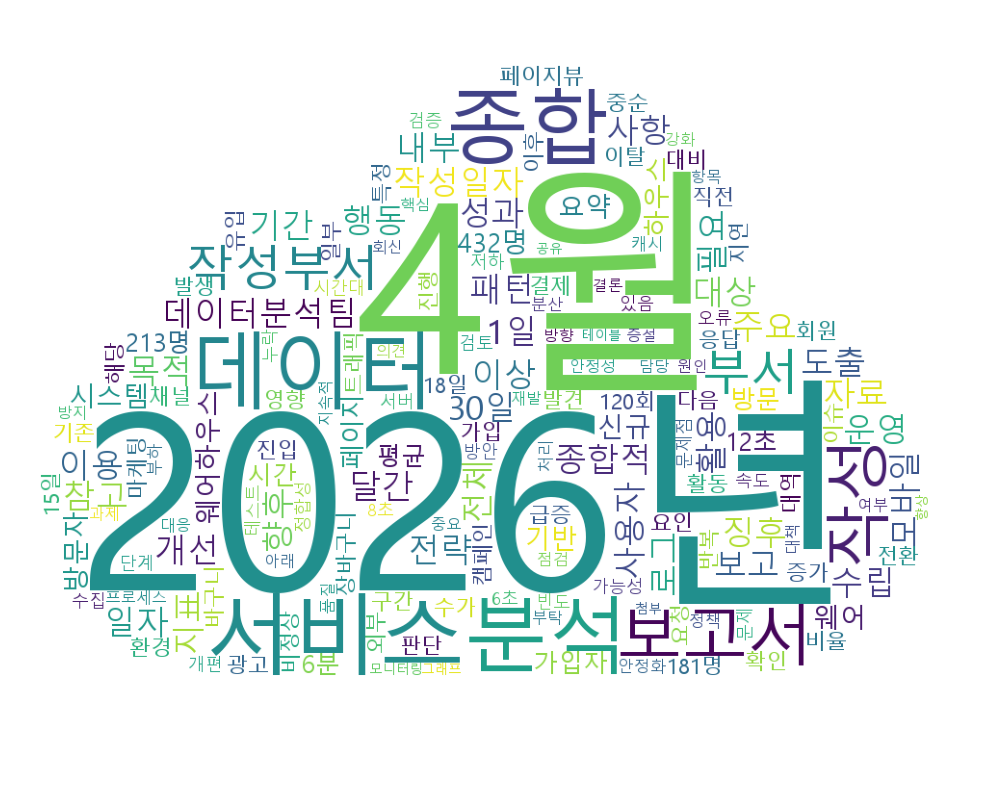

In [80]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordc = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    background_color="white",
    relative_scaling=0.2,
    mask=mask_ar)
wordc.generate(text)

plt.figure(figsize=(15,10))
plt.imshow(wordc)
plt.axis("off")
plt.show()